# Capstone Project – NLP Applications

In [ ]:
# Import the libraries needed for data handling, NLP, and visualisation
import pandas as pd
import spacy
import matplotlib.pyplot as plt
%matplotlib inline 
from collections import Counter
from spacytextblob.spacytextblob import SpacyTextBlob

In [2]:
# Load the medium-sized English model
nlp = spacy.load("en_core_web_md")

# Ensure the sentiment analysis component is added to the pipeline
nlp.add_pipe("spacytextblob")
print(nlp.pipe_names)

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'spacytextblob']


## Load the Amazon Product Reviews Dataset

In [3]:
# Load the correct Amazon reviews dataset
file_path = "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"
df = pd.read_csv(file_path)

# Display the first five rows 
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [4]:
# Check the dataset shape and column names
print("Dataset shape:\n", df.shape)
print()
print("Columns:")

for column in df.columns:
    print("--", column)

Dataset shape:
 (28332, 24)

Columns:
-- id
-- dateAdded
-- dateUpdated
-- name
-- asins
-- brand
-- categories
-- primaryCategories
-- imageURLs
-- keys
-- manufacturer
-- manufacturerNumber
-- reviews.date
-- reviews.dateSeen
-- reviews.didPurchase
-- reviews.doRecommend
-- reviews.id
-- reviews.numHelpful
-- reviews.rating
-- reviews.sourceURLs
-- reviews.text
-- reviews.title
-- reviews.username
-- sourceURLs


In [5]:
# Count the missing values in the reviews.text column
missing_reviews = df["reviews.text"].isna().sum()
print("Missing values in 'reviews.text':", missing_reviews)

Missing values in 'reviews.text': 0


## Cleaning the Amazon Product Reviews

In [6]:
# Remove all missing values from the reviews.text column
df = df.dropna(subset=["reviews.text"]).copy()

# Select the “reviews.text” column from the dataset
reviews_data = df["reviews.text"]

# Display the number of usable reviews
print("Number of usable reviews:", len(reviews_data))
reviews_data.head(10)

Number of usable reviews: 28332


0    I order 3 of them and one of the item is bad q...
1    Bulk is always the less expensive way to go fo...
2    Well they are not Duracell but for the price i...
3    Seem to work as well as name brand batteries a...
4    These batteries are very long lasting the pric...
5    Bought a lot of batteries for Christmas and th...
6    ive not had any problame with these batteries ...
7    Well if you are looking for cheap non-recharge...
8    These do not hold the amount of high power jui...
9    AmazonBasics AA AAA batteries have done well b...
Name: reviews.text, dtype: str

## Preprocessing the Review Text Content 

In [7]:
def preprocess_text(text):
    
    """
    This function cleans each review by using:

    - lower() function: convertes text to lowercase 
    - strip() function: removes extra/unnecessary whitespace  
    - spaCy .is_stop: removes stop words that add little meaning   
    - spaCy .is_punct: removes punctuation 
    - spaCy .is_space: removes regular spacing  
    - spaCy .is_alpha: removes any non-alphabetic tokens 

    Parameters: The pre-cleaned, raw review text (str).
    Returns: The cleaned review text (str).
    """
    
    # Convert to lowercase and remove extra whitespace
    text = str(text).lower().strip()
    
    # Process review text with the NLP model 
    doc = nlp(text)

    cleaned_tokens = [
        token.text
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
    ]

    return " ".join(cleaned_tokens)

In [8]:
# Apply preprocessing to the review text column
df["cleaned_review"] = df["reviews.text"].apply(preprocess_text)

# Display the original and cleaned review side by side
df[["reviews.text", "cleaned_review"]].head(10)

,reviews.text,cleaned_review
0,I order 3 of them and one of the item is bad q...,order item bad quality missing backup spring p...
1,Bulk is always the less expensive way to go fo...,bulk expensive way products like
2,Well they are not Duracell but for the price i...,duracell price happy
3,Seem to work as well as name brand batteries a...,work brand batteries better price
4,These batteries are very long lasting the pric...,batteries long lasting price great
5,Bought a lot of batteries for Christmas and th...,bought lot batteries christmas amazonbasics ce...
6,ive not had any problame with these batteries ...,ve problame batteries ordered past pleased
7,Well if you are looking for cheap non-recharge...,looking cheap non rechargeable batteries perfect
8,These do not hold the amount of high power jui...,hold high power juice like energizer duracell ...
9,AmazonBasics AA AAA batteries have done well b...,amazonbasics aa aaa batteries appear good shel...


## The Sentiment Analysis Function

In [9]:
def analyze_sentiment(review):
    
    """
    Analyse the sentiment of a review using spaCyTextBlob polarity.
    Parameters: A cleaned product review (str).
    Returns: a tuple consisting of (polarity score, sentiment label)
    """
    
    doc = nlp(review)
    
    # Get the polarity with the Textblob polarity attribute 
    polarity = doc._.blob.polarity

    # Assign sentiment labels to different polarity cases 
    if polarity >= 0.8:
        sentiment_label = "Very Positive"
    
    elif polarity > 0:
        sentiment_label = "Positive"

    elif polarity <= -0.8:
        sentiment_label = "Very Negative"
    
    elif polarity < 0:
        sentiment_label = "Negative"

    else:
        sentiment_label = "Neutral"

    return polarity, sentiment_label

In [10]:
# Apply sentiment analysis to every cleaned review
df[["polarity", "sentiment"]] = df["cleaned_review"].apply(lambda review: pd.Series(analyze_sentiment(review)))

# Preview the results
df[["reviews.text", "cleaned_review", "polarity", "sentiment"]].head(15)

,reviews.text,cleaned_review,polarity,sentiment
0,I order 3 of them and one of the item is bad q...,order item bad quality missing backup spring p...,-0.450000,Negative
1,Bulk is always the less expensive way to go fo...,bulk expensive way products like,-0.500000,Negative
2,Well they are not Duracell but for the price i...,duracell price happy,0.800000,Very Positive
3,Seem to work as well as name brand batteries a...,work brand batteries better price,0.500000,Positive
4,These batteries are very long lasting the pric...,batteries long lasting price great,0.250000,Positive
5,Bought a lot of batteries for Christmas and th...,bought lot batteries christmas amazonbasics ce...,0.350000,Positive
6,ive not had any problame with these batteries ...,ve problame batteries ordered past pleased,0.125000,Positive
7,Well if you are looking for cheap non-recharge...,looking cheap non rechargeable batteries perfect,0.700000,Positive
8,These do not hold the amount of high power jui...,hold high power juice like energizer duracell ...,-0.003333,Negative
9,AmazonBasics AA AAA batteries have done well b...,amazonbasics aa aaa batteries appear good shel...,0.700000,Positive


## Testing the Sentiment Function

In [11]:
sample_reviews = [
    "I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.",
    "Bulk is always the less expensive way to go for products like these",
    "Well they are not Duracell but for the price i am happy.",
    "Seem to work as well as name brand batteries at a much better price",
    "These batteries are very long lasting the price is great."
]

for review in sample_reviews:
    
    polarity, sentiment = analyze_sentiment(preprocess_text(review))
    print("Review:", review)
    print(f"Polarity: {polarity:.3f}")
    print("Predicted sentiment:", sentiment)
    print("-" * 100)

Review: I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.
Polarity: -0.450
Predicted sentiment: Negative
----------------------------------------------------------------------------------------------------
Review: Bulk is always the less expensive way to go for products like these
Polarity: -0.500
Predicted sentiment: Negative
----------------------------------------------------------------------------------------------------
Review: Well they are not Duracell but for the price i am happy.
Polarity: 0.800
Predicted sentiment: Very Positive
----------------------------------------------------------------------------------------------------
Review: Seem to work as well as name brand batteries at a much better price
Polarity: 0.500
Predicted sentiment: Positive
----------------------------------------------------------------------------------------------------
Review: These batteries are very long la

## Review Similarity Function - Comparing Reviews

In [12]:
# Select two cleaned reviews from the dataset for comparison
review_1 = nlp(df["cleaned_review"].iloc[0])
review_2 = nlp(df["cleaned_review"].iloc[1])

similarity_score = review_1.similarity(review_2)

print("Review 1:")
print(df["reviews.text"].iloc[0])
print("\nReview 2:")
print(df["reviews.text"].iloc[1])
print(f"\nSimilarity score: {similarity_score:.3f}")

Review 1:
I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.

Review 2:
Bulk is always the less expensive way to go for products like these

Similarity score: 0.732


## Summary Statistics and Visualisations

In [13]:
# Display the sentiment distribution
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts

sentiment
Positive         19853
Very Positive     3354
Neutral           3048
Negative          2044
Very Negative       33
Name: count, dtype: int64

In [14]:
# Display basic descriptive statistics for polarity scores using describe() function
df["polarity"].describe()

count    28332.000000
mean         0.371082
std          0.307865
min         -1.000000
25%          0.136944
50%          0.387500
75%          0.600000
max          1.000000
Name: polarity, dtype: float64

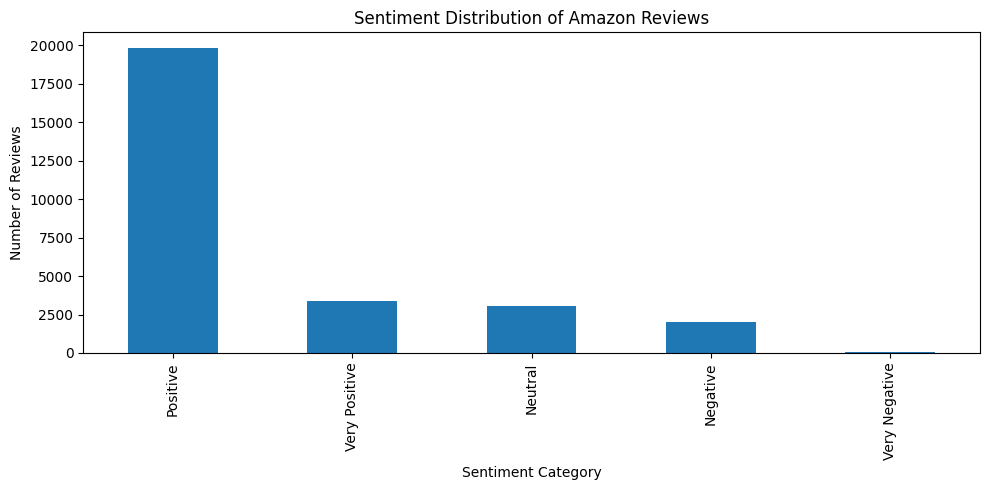

In [15]:
#Set figure size
plt.figure(figsize=(10, 5))

# Create a bar plot to show number of reviews in each sentiment category
sentiment_counts.plot(kind="bar")

#Add plot x,y labels and title
plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")
plt.tight_layout()

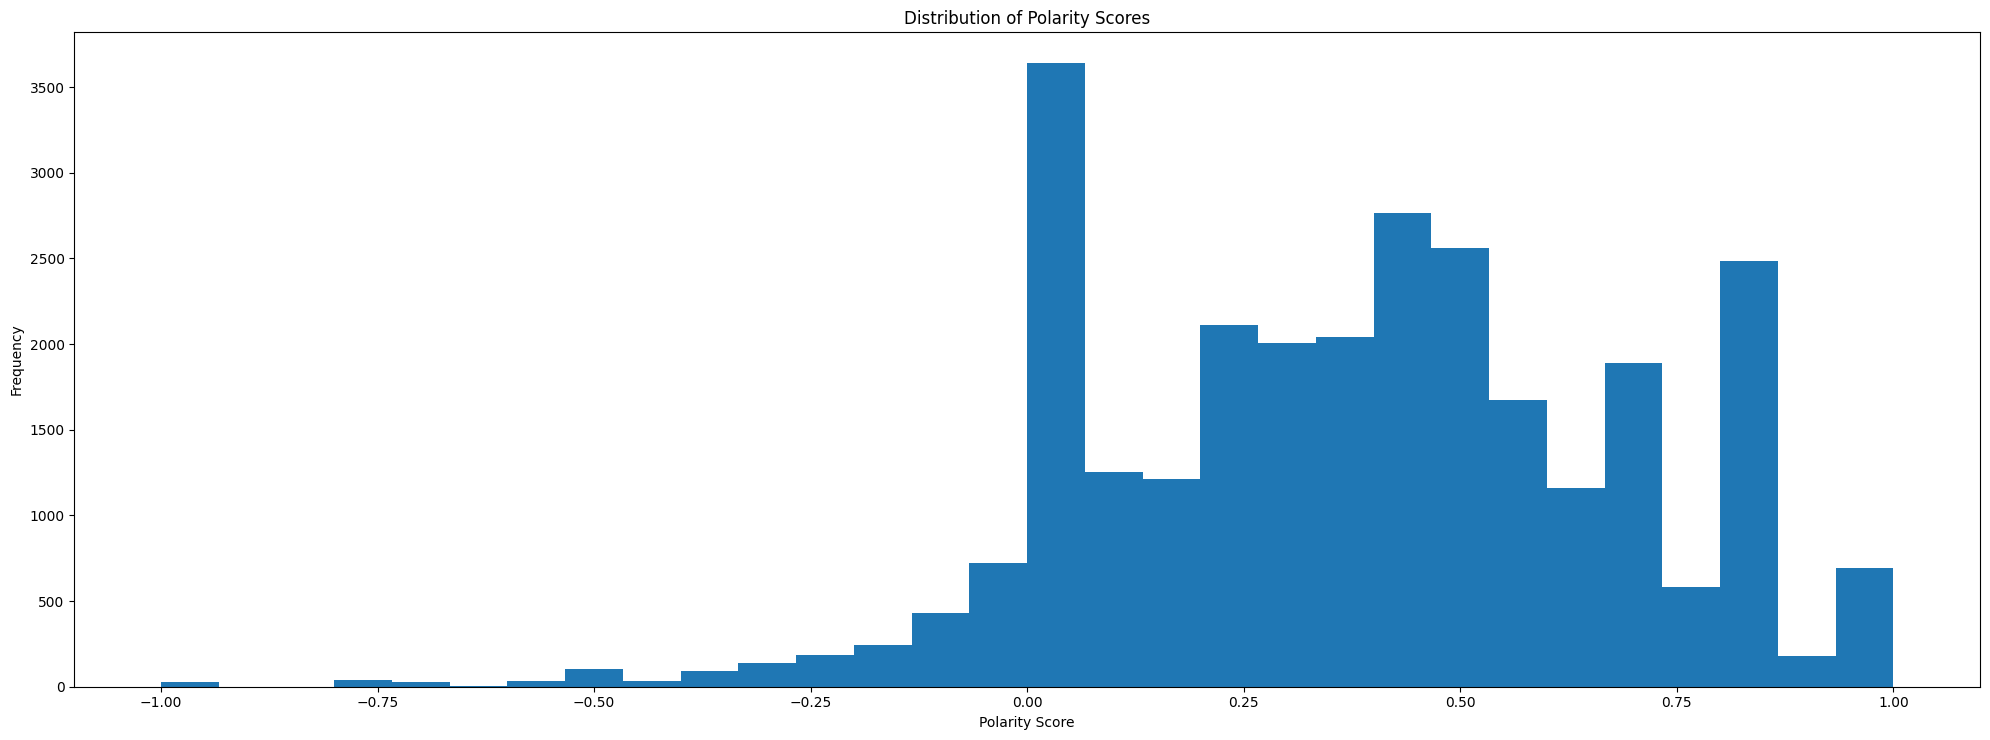

In [ ]:
# Set figure size
plt.figure(figsize=(20, 7.5))

# Create a histogram chart to show spread of polarity scores
plt.hist(df["polarity"], bins=30)

# Add chart x,y label labels and title
plt.title("Distribution of Polarity Scores")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.tight_layout()

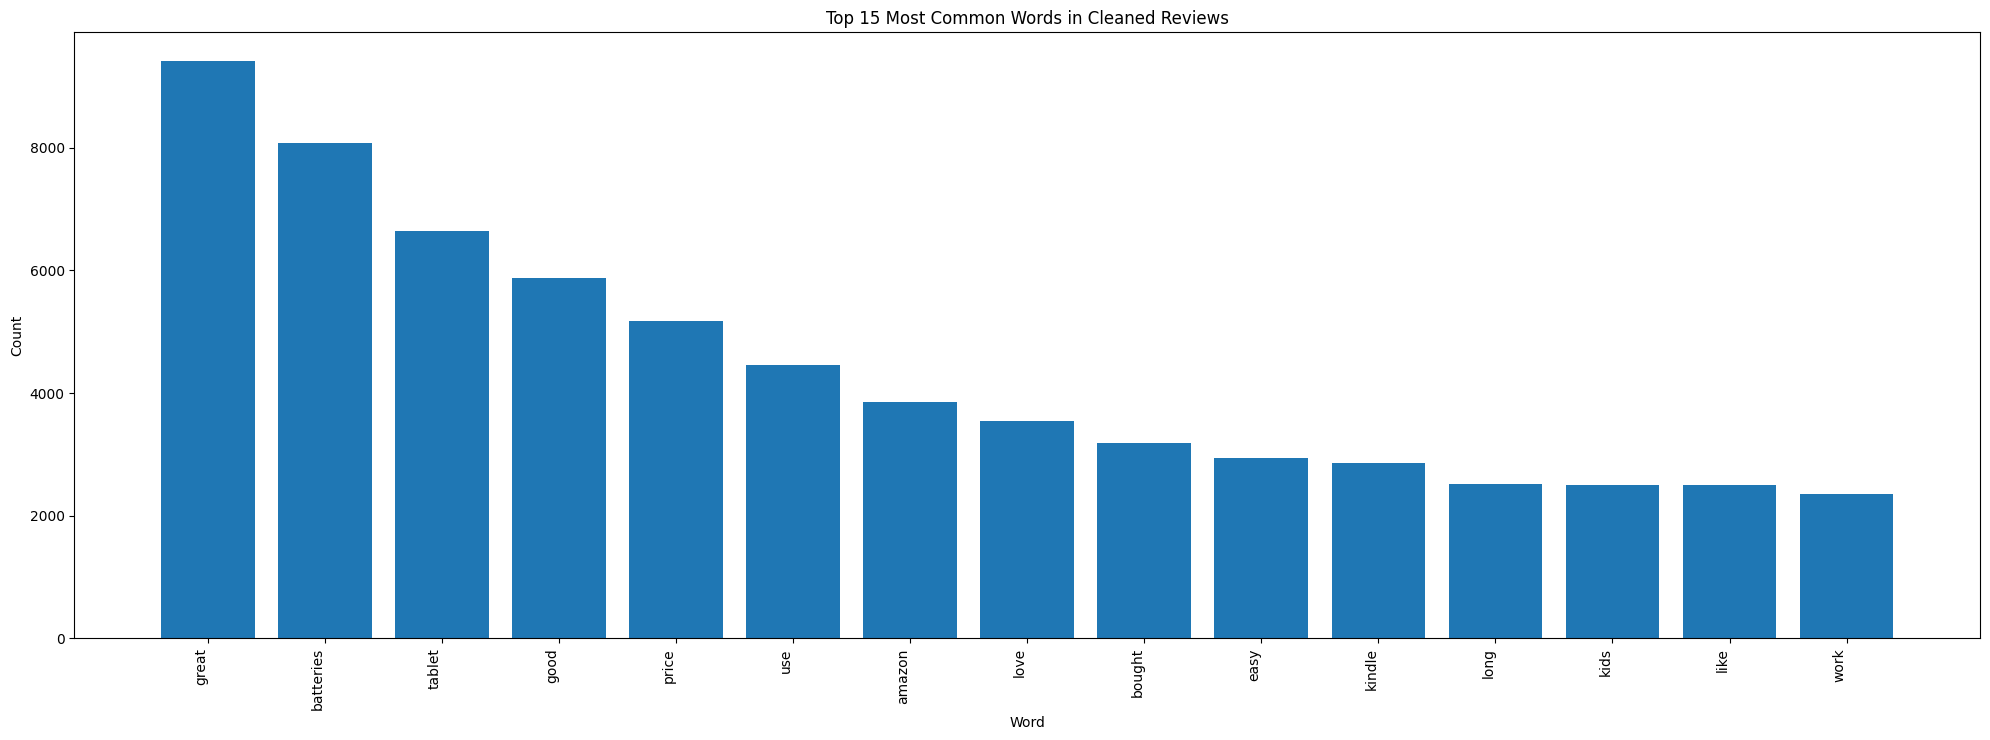

In [ ]:
# Count the most common words in cleaned reviews
all_words = " ".join(df["cleaned_review"]).split()
word_counts = Counter(all_words)

# Get the 15 most common words
most_common_words = word_counts.most_common(15)

words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

# Set figure size
plt.figure(figsize=(20, 7.5))
plt.bar(words, counts)

# Add chart x,y label labels and title
plt.title("Top 15 Most Common Words in Cleaned Reviews")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()

## Example Reviews

In [18]:
# Display an example from each sentiment category
for label in ["Very Positive", "Positive", "Neutral", "Negative", "Very Negative"]:
    print(f"\n{label} review examples:")
    sample = df[df["sentiment"] == label]["reviews.text"].head(3)

    if len(sample) == 0:
        print("No examples found.")

    else:
        for i, review in enumerate(sample, start=1):
            print(f"{i}. {review}")


Very Positive review examples:
1. Well they are not Duracell but for the price i am happy.
2. we have many things that need aa battery they are great
3. Seem to work very well at a great price.

Positive review examples:
1. Seem to work as well as name brand batteries at a much better price
2. These batteries are very long lasting the price is great.
3. Bought a lot of batteries for Christmas and the AmazonBasics Cell have been good. I haven't noticed a difference between the brand name batteries and the Amazon Basic brand. Just a lot easier to purchase and have arrive at the house and have on hand. Will buy again.

Neutral review examples:
1. Date on the back of these were 1992. Yeah, 1992. Inedible.
2. GOT THE 48 PACK, I USEDD THEM UP FASTER THAN I THOUGHT I WOULD!!,SO IM ORDERING MORE !! SO IM ORDERING MORE NOW
3. They're batteries!

Negative review examples:
1. I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make

In [1]:
print("Key Insight:")
print("Negative reviews frequently mention delivery delays and product quality issues.")
print("Positive reviews are associated with pricing and ease of use.")

Key Insight:
Negative reviews frequently mention delivery delays and product quality issues.
Positive reviews are associated with pricing and ease of use.
